# EPUG -- Training your own neural network for image analysis with PyTorch

In [1]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    data_dir = "./"
else:
    data_dir = "./data/"

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from imageio.v2 import imread
from tqdm import tqdm

In [ ]:
# !pip install cifar2png
# cifar_dir = './data/cifar10'
# !cifar2png cifar10 ./data/cifar10

In [4]:
cifar_dir = f'{data_dir}/cifar10'

In [5]:
# first, list the categories available in the data
data_dir = os.path.join(cifar_dir, "train")
categories = os.listdir(data_dir)
categories.sort()
print(categories)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Download and read the data

We download and load the images and corresponding labels to inspect them (and later use it to train a classifier).

The data is organised in a folder structure as follows:

```
train/
  airplane/
    001.png
    002.png
    ...
  automobile/
    001.png
    002.png
    ...
```

and similarly for the test data.

In [6]:
# next load the images and labels
images = []
labels = []
for label_id, category in tqdm(enumerate(categories), total=len(categories)):
    category_dir = os.path.join(data_dir, category)
    image_names = os.listdir(category_dir)
    for im_name in image_names:
        im_file = os.path.join(category_dir, im_name)
        images.append(imread(im_file))
        labels.append(label_id)

# make numpy arrays out of the lists
# for th images, we stack along a new first axis
images = np.concatenate([im[None] for im in images], axis=0)
labels = np.array(labels)

print("Number of images:", len(images))
print("Number of labels:", len(labels))

100%|██████████| 10/10 [00:17<00:00,  1.78s/it]

Number of images: 50000
Number of labels: 50000


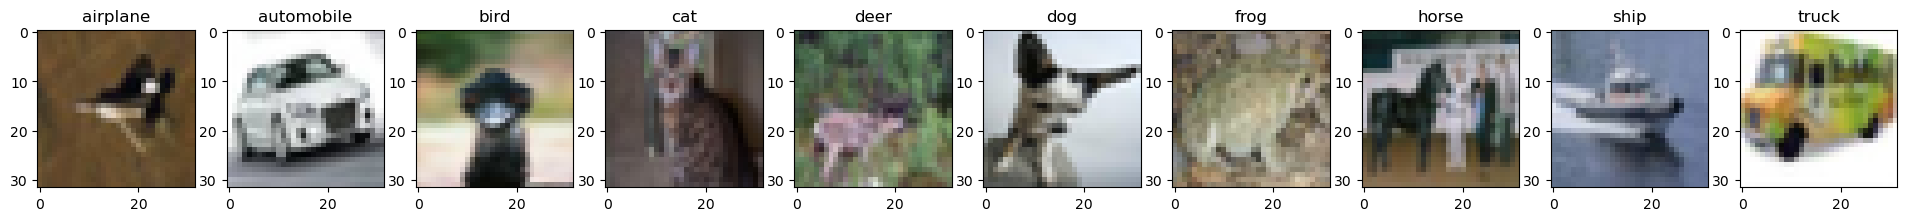

In [7]:
# plot one image for each category
fig, ax = plt.subplots(1, 10, figsize=(24, 6))
label_list = labels.tolist()
for label_id, category in enumerate(categories):
    ax[label_id].imshow(images[label_list.index(label_id)])
    ax[label_id].set_title(category)
plt.show()

## Preparations for Pytorch -- Minimal Dataset

In order to use the CIFAR data to with pytorch, we need to transform the data into the compatible data structures. In particular, pytorch expects all numerical data as [torch.tensor](https://pytorch.org/docs/stable/tensors.html).
To provide the data as tensors, we will wrap them in a [torch.dataset](https://pytorch.org/docs/stable/data.html) and implement a mechanism to apply transformations to the data on the fly. We will use these transformations to bring the data into a format that pytorch can ingest and later also use them for other purposes such as data augmentation.

In [8]:
import torch
# datasets have to be sub-classes from torch.util.data.Dataset
from torch.utils.data import Dataset

class DatasetWithTransform(Dataset):
    """ Our minimal dataset class. It holds data and target
    as well as optional transforms that are applied to the data and target
    on the fly when a batch is requested via the [] operator.
    """
    def __init__(self, data, target, transform=None):
        assert isinstance(data, np.ndarray)
        assert isinstance(target, np.ndarray)
        self.data = data
        self.target = target
        if transform is not None:
            assert callable(transform)
        self.transform = transform

    # exposes the [] operator of our class
    def __getitem__(self, index):
        data, target = self.data[index], self.target[index]

        # if we have transformations, apply them to the data and target
        if self.transform is not None:
            data, target = self.transform(data, target)
        return data, target

    def __len__(self):
        return self.data.shape[0]

### Image Transformations

#### What shape are the images?

In [9]:
print(images[0].shape)

(32, 32, 3)


In [10]:
# as we see, the images are stored in the order width, height, channel (WHC),
# i.e. the first two axes are the image axes and the last axis
# corresponds to the color channel.
# pytorch however expects the color channel as first axis, i.e. CWH.
# so our first transform switches the chanels

# note that we have implemented the dataset in such a way, that the transforms
# are functions that take both the data (or image) and target as parameters.
# thus we here accept the target (which is just the class label for the image)
# as second parameter and return it without changing it
def to_channel_first(image, target):
    """ Transform images with color channel last (WHC) to channel first (CWH)
    """
    # put channel first
    image = image.transpose((2, 0, 1))
    return image, target

#### What datatype are the images? What range of values?

In [11]:
# next, let's see what datatype and value range our images have
print(images[0].dtype)
print(images[0].min(), images[0].max())

uint8
1 236


In [12]:
# as we can see, the images are stored as 8 bit integers with a value range [0, 255]
# instead, torch expects images as 32 bit floats that should also be normalized to a 'reasonable' data range.
# here, we normalize the image such that all channels are in range 0 to 1
def normalize(image, target, channel_wise=True):
    eps = 1.e-6
    image = image.astype('float32')
    if not channel_wise:
        image /= (image.max() + eps)
        return image, target
    else:
        chan_min = image.min(axis=(1, 2), keepdims=True)
        image -= chan_min
        chan_max = image.max(axis=(1, 2), keepdims=True)
        image /= (chan_max + eps)
    return image, target

In [13]:
# finally, we need to transform the input from a numpy array to a torch tensor
# and also return the target (which in our case is a scalar) as a tensor
def to_tensor(image, target):
    return torch.from_numpy(image), torch.tensor([target], dtype=torch.int64)

#### How to combine the transformations?

In [14]:
# we also need a way to apply multiple transforms
# (note that alternatively we could also have accepted a list of transforms
# in DatasetWithTransform)
def compose(image, target, transforms):
    for trafo in transforms:
        image, target = trafo(image, target)
    return image, target

## Lets try out our Dataset

In [15]:
# create the dataset with the transformations
from functools import partial  # to bind function arguments

trafos = [to_channel_first, normalize, to_tensor]
trafo = partial(compose, transforms=trafos)

dataset = DatasetWithTransform(images, labels, transform=trafo)

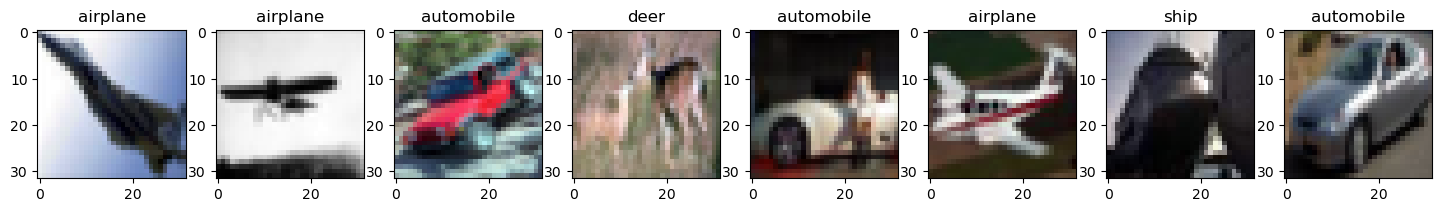

In [16]:
# function to show an image target pair returned from the dataset
def show_image(ax, image, target):
    # need to go back to numpy array and WHC axis order
    image = image.numpy().transpose((1, 2, 0))
    # find the label name
    label = categories[target.item()]
    ax.imshow(image)
    ax.set_title(label)


# sample a few images from the dataset and check their label
n_images = len(dataset)
n_samples = 8

fig, ax = plt.subplots(1, n_samples, figsize=(18, 4))
for sample in range(n_samples):
    # datasets are random access, so we can request
    # an image / target at an arbitrary index
    sample_id = np.random.randint(0, n_images)
    image, target = dataset[sample_id]

    # make sure that the image is in range 0, 1
    assert np.isclose(image.min(), 0.)
    assert np.isclose(image.max(), 1.)

    # add the image to our plots
    show_image(ax[sample], image, target)

A note

# Models with Pytorch

In pytorch models are defined by a class that inherits from `nn.Module`.
This allows to add member variables (that are sub-classes of `nn.Module` themselves) so that these are handled correctly in auto differentiation.
The forward pass of a model is defined in the member function `forward`, the backward pass will be automatically generated.

In [17]:
import torch.nn as nn
import torch.nn.functional as F

## Logistic Regression

Here, we define a simple network consisting of a single fully connected layer that receives the image as input.
When trained with cross entropy loss, this model corresponds to a logistic regressor.

In fully connected layers, we apply a linear transformation (weight term *w_jk* and a bias term *w_j0*) to the input (input term *x_i*), whose product is then applied with a non-linear transformation (*f*). 

<img src="./images/FCL-eq.jpg" width="300" height="100">

[Image reference](https://builtin.com/machine-learning/fully-connected-layer)

Visually it looks something like this. #1,2,...,9 nodes are input nodes, and A,...,D nodes are output nodes. The edges represent each weight getting applied. 

<img src="./images/FCL-0.jpg" width="300" height="300">


[Image reference](https://builtin.com/machine-learning/fully-connected-layer)

#### If you want to learn more

[3Blue1Brown's really cool introduction to neural network](https://www.youtube.com/watch?v=aircAruvnKk)

[StatQuest's gentle introduction to neural network](https://www.youtube.com/watch?v=CqOfi41LfDw)

In [18]:
# define logistic regression model
class LogisticRegressor(nn.Module):
    def __init__(self, n_pixels, n_classes):
        # the parent class 'nn.Module' needs to be initialised so
        # that all members that are subclasses of nn.Module themselves
        #  are correctly handled in autodiff
        super().__init__()
        self.n_pixels = n_pixels
        self.n_classes = n_classes
        # nn.Sequential applies its arguments one after the other 
        self.log_reg = nn.Sequential(
            # nn.Linear instantiates a fully connected layer, the first argument
            # specifies the number of input units, the second argument the number
            # of output units
            nn.Linear(self.n_pixels, self.n_classes),
            # logarithmic softmax activation.
            # the combination of LogSoftmax and negative log-likelihood loss
            # (see below) corresponds to training with Cross Entropy, but is
            # numerically more stable
            nn.LogSoftmax(dim=1)
        )
        
    def forward(self, x):
        # reshape the input to be 1d instead of 2d,
        # which is required for fully connected layers
        # Turns input from something like (batch_size, channels, height, width) 
        # to (batch_size, n_pixels)
        x = x.view(-1, self.n_pixels)
        x = self.log_reg(x)
        return x

## Multi-Layer Perceptron (MLP)

Now we go from a single layer network to a network with multiple layers, also known as multi-layer perceptron, or MLP. In this architecture, we will have 'hidden layers', i.e. layers that receive input not from the input directly but from previous layers in the network and that are not directly observed in the output.
We still use fully connected layers (`nn.Linear`), i.e. each neuron in a given layer receives input from all neurons in the previous layer.

Imporantly, we apply a non-linearity to all layer outputs.
Otherwise, the layers could be collapsed into a single layer by matrix multiplication.

In [19]:
class MLP(nn.Module):
    def __init__(self, n_pixels, n_classes):
        super().__init__()
        self.n_pixels = n_pixels
        self.n_classes = n_classes
        
        # here, we define the structure of the MLP.
        # it's imporant that we use a non-linearity after each 
        # fully connected layer! Here we use the rectified linear
        # unit, short ReLu
        self.layers = nn.Sequential(
            nn.Linear(n_pixels, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, n_classes),
            nn.LogSoftmax(dim=1)
        )
    
    def forward(self, x):
        x = x.view(-1, self.n_pixels)
        x = self.layers(x)
        return x

## Convolutional Neural Network (CNN)

Define the model architecture for our first CNN. The network is made up of the following components:
- convolutional layers that convolve their input with a learnable filter, using less parameters than a fully connected layer while keeping spatial context
- max pooling that halves the image size
- fully connected layers at the end of the network to output a class prediction vector for the input

Note that both convolutional layers and pooling operations change the spatial
size of the data. You can find the formulas for this in the torch class descriptions: [nn.Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#conv2d), [nn.MaxPool2d](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html).
See the comments in network definition below for an example.

<img src="./images/2D_Convolution_Animation.gif" width="400" height="300">

In convoluntional neural networks we are convoling a kernel with the image. Image convolution can be understood as each pixel ("origin") calculated by a surrounding sliding window of the image as a element-wise product with the convolutional kernel followed by a summation.

Image reference: [Wikipedia page of Kernel](https://en.wikipedia.org/wiki/Kernel_(image_processing))

### What is a convolutional kernel?

We can think of a kernel as a small matrix that can be convolved with our image to produce an effect. Or more simply, when each pixel in the output image is a function of the nearby pixels (including itself) in the input image, the kernel is the function.

We could take pre-defined convolutional kernels designed for specific image operations and from classical image processing. [skimage.filters](https://scikit-image.org/docs/dev/api/skimage.filters.html).



#### If you want to learn more... check out this excellent explanation!
[Youtuber Computerphile's explanation](https://www.youtube.com/watch?v=C_zFhWdM4ic)

In [20]:
import skimage.filters as filters
image = images[0]
filtered_gaussian = filters.gaussian(image, sigma=1.)
filtered_laplacian = filters.laplace(image)

**Gaussian kernels** extract low-frequency/large-scale content of an image. Smoothing noise and fine texture, but keeping broad shapes and gradual intensity changes.


**Laplacian kernels** extract rapid intensity changes. Emphasises edges and fine details.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.607843137254902..1.1764705882352944].


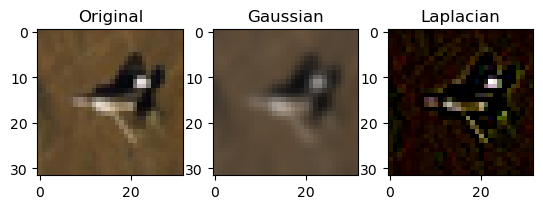

In [21]:
fig, ax = plt.subplots(1, 3)
ax[0].imshow(image)
ax[0].set_title("Original")
ax[1].imshow(filtered_gaussian)
ax[1].set_title("Gaussian")
ax[2].imshow(filtered_laplacian)
ax[2].set_title("Laplacian")
plt.show()

In a CNN we don't want to pre-define our convolutional kernels, but allow the model to **learn** the best kernels based on the data.

In [22]:
class CNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.n_classes = n_classes

        # the convolutions
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)

        # the fully connected part of the network
        # after applying the convolutions and poolings, the tensor
        # has the shape 24 x 6 x 6, see below
        self.fc = nn.Sequential(
            nn.Linear(24 * 6 * 6, 120),
            nn.ReLU(),
            nn.Linear(120, 60),
            nn.ReLU(),
            nn.Linear(60, self.n_classes)
        )
        # The fully connected layer performs dimensionality reduction 
        # from 24*6*6 to 120, then to 60 and finally to the number of classes.
        # Giving an output that corresponds to the classification task.
        self.activation = nn.LogSoftmax(dim=1)

    def apply_convs(self, x):
      # input image has shape 3 x  32 x 32
      x = self.pool(F.relu(self.conv1(x)))
      # shape after conv: 12 x 28 x 28
      # shape after pooling: 12 x 14 X 14
      x = self.pool(F.relu(self.conv2(x)))
      # shape after conv: 24 x 12 x 12
      # shape after pooling: 24 x 6 x 6
      return x
    
    def forward(self, x):
        x = self.apply_convs(x)
        x = x.view(-1, 24 * 6 * 6)
        x = self.fc(x)
        x = self.activation(x)
        return x

## Training and Validation Loop

Now, we will write functions to train a model for one epoch and a function to validate it after an epoch.
Here, an `epoch` means iterating through the available training data once.

In order to monitor the progress during training, we will use [tensorboard](https://www.tensorflow.org/tensorboard).

In [23]:
def train(model, loader, 
          loss_function, optimizer,
          device, epoch,
          tb_logger, log_image_interval=100):
    """ Train model for one epoch.
    
    Parameters:
    model - the model we are training
    loader - the data loader that provides the training data
        (= pairs of images and labels)
    loss_function - the loss function that will be optimized
    optimizer - the optimizer that is used to update the network parameters
        by backpropagation of the loss
    device - the device used for training. this can either be the cpu or gpu
    epoch - which trainin eppch are we in? we keep track of this for logging
    tb_logger - the tensorboard logger, it is used to communicate with tensorboard
    log_image_interval - how often do we send images to tensborboard?
    """

    # set model to train mode
    model.train()
    
    # iterate over the training batches provided by the loader
    n_batches = len(loader)
    for batch_id, (x, y) in enumerate(loader):
       
        # send data and target tensors to the active device
        x = x.to(device)
        y = y.to(device)
        
        # set the gradients to zero, to start with "clean" gradients
        # in this training iteration
        optimizer.zero_grad()
        
        # apply the model to get the prediction
        prediction = model(x)
        
        # calculate the loss (negative log likelihood loss)
        # the loss function expects a 1d tensor, but we get a 2d tensor
        # with singleton second dimension, so we get rid of this dimension
        loss_value = loss_function(prediction, y[:, 0])
        
        # calculate the gradients (`loss.backward()`) 
        # and apply them to the model parameters with
        # to our optimizer (`optimizer.step()`)
        loss_value.backward()
        optimizer.step()
        
        # log the loss value to tensorboard
        step = epoch * n_batches + batch_id
        tb_logger.add_scalar(tag='train-loss', 
                             scalar_value=loss_value.item(),
                             global_step=step)
        
        # check if we log images, and if we do then send the
        # current image to tensorboard
        if log_image_interval is not None and step % log_image_interval == 0:
            tb_logger.add_images(tag='input', 
                                 img_tensor=x.to('cpu'),
                                 global_step=step)

In [24]:
import sklearn.metrics as metrics #pyright: ignore

# the validation function takes the model, runs prediction for
# all images provided by the loader and evaluates the results.
def validate(model, loader, loss_function, 
             device, step, tb_logger=None):
    """
    Validate the model predictions.
    
    Parameters:
    model - the model to be evaluated
    loader - the loader providing images and labels
    loss_function - the loss function
    device - the device used for prediction (cpu or gpu)
    step - the current training step. we need to know this for logging
    tb_logger - the tensorboard logger. if 'None', logging is disabled
    """
    # set the model to eval mode
    model.eval()
    n_batches = len(loader)
   
    # we record the loss and the predictions / labels for all samples
    mean_loss = 0
    predictions = []
    labels = []
    
    # the model parameters should not be updated during validation
    # torch.no_grad disables gradient updates in its scope
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            prediction = model(x)
            
            # update the loss 
            mean_loss += loss_function(prediction, y[:, 0]).item()
    
            # compute the most likely class predictions
            # note that 'max' returns a tuple with the 
            # index of the maximun value (which correponds to the predicted class)
            # as second entry
            prediction = prediction.max(1, keepdim=True)[1]

            # store the predictions and labels
            predictions.append(prediction[:, 0].to('cpu').numpy())
            labels.append(y[:, 0].to('cpu').numpy())
      
    # predictions and labels to numpy arrays
    predictions = np.concatenate(predictions)
    labels = np.concatenate(labels)
    
    # log the validation results if we have a tensorboard
    if tb_logger is not None:
        
        accuracy_error = 1. - metrics.accuracy_score(labels, predictions)
        mean_loss /= n_batches
        
        tb_logger.add_scalar(tag="validation-error",
                             global_step=step,
                             scalar_value=accuracy_error)
        tb_logger.add_scalar(tag="validation-loss",
                             global_step=step,
                             scalar_value=mean_loss)

    # return all predictions and labels for further evaluation
    return predictions, labels

## Now we are ready to TRAIN right???

Almost....

First we need to set everything up to be ready to train.
-   Train/validation split
-   Instantiate DataLoaders
-   Instantiate model
-   Instantiate the Optimizer
-   Instantiate the Loss

### Train vs Validation Split of data

In [25]:
# split the data into train and validation
# using 'train_test_split' from sklearn the data is shuffled and
# stratified, i.e. the same number of samples per classes 
# is present in the train and validation split
from sklearn.model_selection import train_test_split # pyright: ignore

n_images = len(images)
(train_images, val_images,
 train_labels, val_labels) = train_test_split(images, labels, shuffle=True,
                                              test_size=0.15, stratify=labels)
assert len(train_images) == len(train_labels)
assert len(val_images) == len(val_labels)
assert len(train_images) + len(val_images) == n_images

print("Split cifar into training and validation data:")
print("Have", len(train_images), "training images and", len(val_images), "validation images")

Split cifar into training and validation data:
Have 42500 training images and 7500 validation images


In [26]:
# create the torch datasets for training and validation
from functools import partial

trafos = [to_channel_first, normalize, to_tensor]
trafos = partial(compose, transforms=trafos)

train_dataset = DatasetWithTransform(train_images, train_labels,
                                           transform=trafos)

val_dataset = DatasetWithTransform(val_images, val_labels,
                                         transform=trafos)

### Instantiate the Pytorch Dataloaders

Don't you mean Dataset??? Actually no when we train a NN we need to deal with `Dataset`s and `DataLoader`s. A `Dataset` loads a single instance of your data via the `__getitem__()` function. A `DataLoader` controls retruning batches of data and is what we use to feed data to our model. The Pytorch `DataLoader` uses the `Dataset` to load data and groups them into batches, we can control this batching process by arguments given to the `DataLoader`.

In [27]:
# instantiate the DataLoaders
# torch DataLoaders provide data from a dataset so that it can be ingested by the model.
# the most important aspect is that the data is stacked along the
# batch axis (which is the first axis in torch convention)
from torch.utils.data import DataLoader

# the loader for training: we train with 4 batches per sample
# and shuffle the data
batch_size = 4
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size, 
                          shuffle=True)

# the loader for validation: we use a larger batch size and 
# don't need to shuffle the data
val_loader = DataLoader(val_dataset, batch_size=25)

### Instantiate the model

In [28]:
# instantiate the model
n_pixels = images[0].size  # number of pixels = 3 * 32 * 32
n_classes = 10    
lg_model = LogisticRegressor(n_pixels, n_classes)

In [29]:
# check if we have gpu support
# if you run these exercises on colab, you can use the free colab gpus:
# (however they are not activated by default)
# to activate the gpu on colab, go to 'Runtime->Change runtime type'. 
# Then select 'GPU' in 'Hardware accelerator' and click 'Save'
have_gpu = torch.cuda.is_available()
# we need to define the device for torch, yadda yadda
if have_gpu:
    print("GPU is available")
    device = torch.device('cuda')
else:
    print("GPU is not available, training will run on the CPU")
    device = torch.device('cpu')

# with '.to' the parameters of the model (or any other subclass of torch.nn.Module)
# are sent to the specified device, which can be the cpu or a gpu
lg_model.to(device)

GPU is not available, training will run on the CPU


LogisticRegressor(
  (log_reg): Sequential(
    (0): Linear(in_features=3072, out_features=10, bias=True)
    (1): LogSoftmax(dim=1)
  )
)

### Instantiate the Optimizer

In [30]:
# instantiate the optimizer
# the optimizer applies the gradients of the loss to the model parameters by some variant of stochastic gradient descent
# here, we use the Adam optimizer 
# https://pytorch.org/docs/stable/optim.html#torch.optim.Adam
from torch.optim import Adam

# the most important parameter to the optimizer is the 
# learning rate, which is multiplied as a factor to the gradients during
# the parameter update
lg_optimizer = Adam(lg_model.parameters(), lr=1.e-3)

#### If you want to learn more...
Adam optimizer is an optimization algorithm that minimizes the cost function of the network and, more specifically, is inspired by stochastic gradient descent that uses a momentum. 


1) [IBM's really gentle introduction to grandient descent](https://www.youtube.com/watch?v=i62czvwDlsw)
2) [StatQuest's step-by-step explanation on stochastic gradient descent](https://www.youtube.com/watch?v=vMh0zPT0tLI)
3) [Andrew Ng's explanation on Adam optimizer](https://www.youtube.com/watch?v=JXQT_vxqwIs)

### Instantiate the Loss

In [31]:
# instantiate the loss function 
# here, we use the negative log likelihood loss
# combined with the LogSoftmax activation (see model definition)
# this corresponds to the CrossEntropy loss, but is numerically more stable
loss_function = nn.NLLLoss()
loss_function.to(device)

NLLLoss()

### Setup the Logging

In [32]:
# clear the tensorboard logs if they exist
# skip this step if you want to keep the logs of a previous
from shutil import rmtree
try:
    rmtree('runs/log_reg')
except OSError:
    pass

In [34]:
# instantiate the tensorboard logger that will be passed to the
# training and validation functions
from torch.utils.tensorboard import SummaryWriter
lg_tb_logger = SummaryWriter('runs/log_reg')

# this magic command will open tensorboard inside of our notebook
# click on the refresh symbol after the training (see below) has finished
# to see the training progress log
%load_ext tensorboard
%tensorboard --logdir runs --port 0

Reusing TensorBoard on port 55224 (pid 93446), started 0:15:37 ago. (Use '!kill 93446' to kill it.)

## OK we made it!!! Lets Train 

### Train the Logistic Regression Model

In [35]:
# run training for a couple of epochs
from tqdm import trange  # progress bar for the overall training
n_epochs = 6
for epoch in trange(n_epochs):
    train(lg_model, train_loader, loss_function, lg_optimizer,
          device, epoch, tb_logger=lg_tb_logger)
    step = (epoch + 1) * len(train_loader)
    validate(lg_model, val_loader, loss_function,
             device, step,
             tb_logger=lg_tb_logger)

100%|██████████| 6/6 [00:37<00:00,  6.20s/it]


### Train the MLP model

In [36]:
# instantiate the model
mlp_model = MLP(3072, 10)
mlp_model.to(device)

# instantiate optimizer
mlp_optimizer = Adam(mlp_model.parameters(), lr=1.e-4)

# instantiate the loss function
mlp_loss_function = nn.NLLLoss()
mlp_loss_function.to(device)

# setup tensorboard logger
mlp_tb_logger = SummaryWriter('runs/mlp')

In [37]:
# train for a couple of epochs
n_epochs = 6
for epoch in trange(n_epochs):
    train(mlp_model, train_loader, mlp_loss_function, mlp_optimizer,
                device, epoch, tb_logger=mlp_tb_logger)
    step = (epoch + 1) * len(train_loader)
    validate(mlp_model, val_loader, mlp_loss_function,
                   device, step,
                   tb_logger=mlp_tb_logger)

100%|██████████| 6/6 [04:11<00:00, 41.90s/it]


### Train the CNN Model

In [38]:
# instantiate the model
cnn_model = CNN(n_classes=10)
cnn_model.to(device)

# instantiate optimizer
cnn_optimizer = Adam(cnn_model.parameters(), lr=1.e-3)

# instantiate the loss function
cnn_loss_function = nn.NLLLoss()
cnn_loss_function.to(device)

# setup tensorboard logger
cnn_tb_logger = SummaryWriter('runs/cnn')

In [39]:
# train for a couple of epochs
n_epochs = 6
for epoch in trange(n_epochs):
    train(cnn_model, train_loader, cnn_loss_function, cnn_optimizer,
                device, epoch, tb_logger=cnn_tb_logger)
    step = (epoch + 1) * len(train_loader)
    validate(cnn_model, val_loader, cnn_loss_function,
                   device, step,
                   tb_logger=cnn_tb_logger)

100%|██████████| 6/6 [01:53<00:00, 18.97s/it]


## Evaluating the Performance of our models

In [40]:
from utils import make_cifar_test_dataset

# evaluate the model on test data
test_dataset = make_cifar_test_dataset(cifar_dir)
test_loader = DataLoader(test_dataset, batch_size=25)

100%|██████████| 10/10 [00:03<00:00,  2.85it/s]


In [41]:

lg_predictions, lg_labels = validate(lg_model, test_loader, loss_function,
                                     device, step=0, tb_logger=None)

Test accuracy:
0.3327


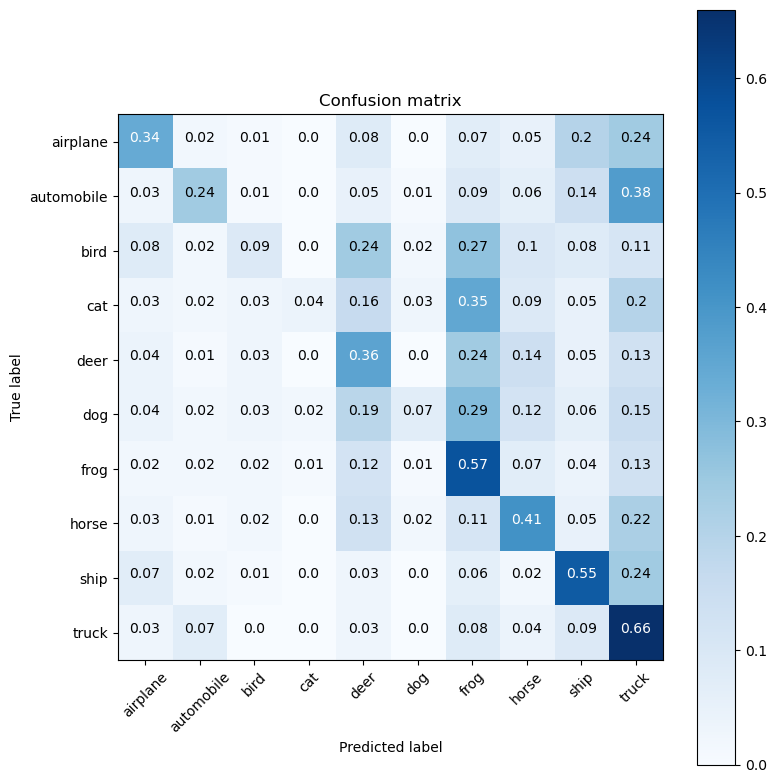

In [42]:
import matplotlib.pyplot as plt
from utils import make_confusion_matrix
print("Test accuracy:")
accuracy = metrics.accuracy_score(lg_labels, lg_predictions)
print(accuracy)

fig, ax = plt.subplots(1, figsize=(8, 8))
make_confusion_matrix(lg_labels, lg_predictions, categories, ax)

Test accuracy:
0.4732


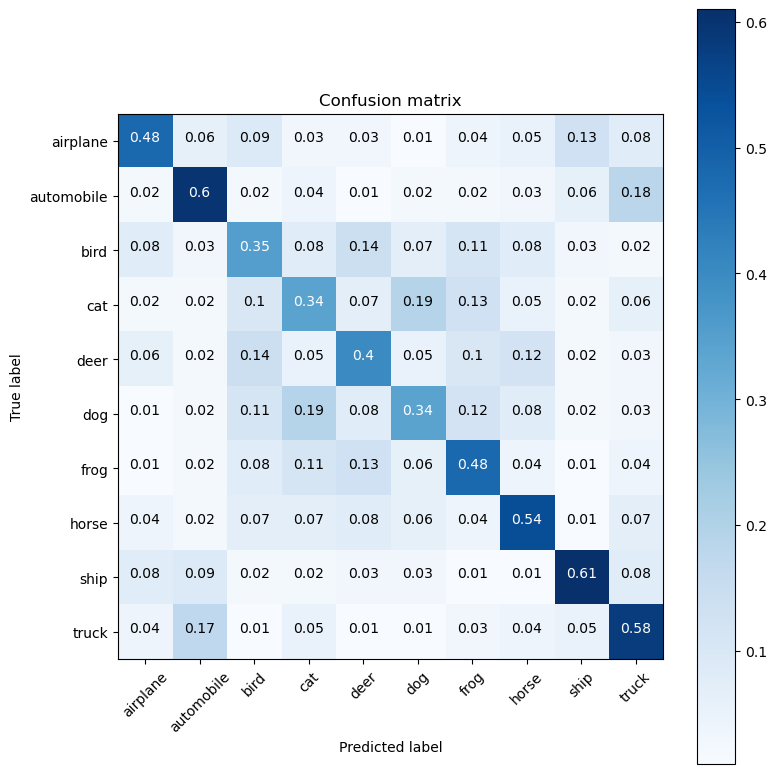

In [44]:
mlp_predictions, mlp_labels = validate(mlp_model, test_loader, mlp_loss_function,
                                     device, step=0, tb_logger=None)

import matplotlib.pyplot as plt
from utils import make_confusion_matrix
print("Test accuracy:")
accuracy = metrics.accuracy_score(mlp_labels, mlp_predictions)
print(accuracy)

fig, ax = plt.subplots(1, figsize=(8, 8))
make_confusion_matrix(mlp_labels, mlp_predictions, categories, ax)

Test accuracy:
0.5977


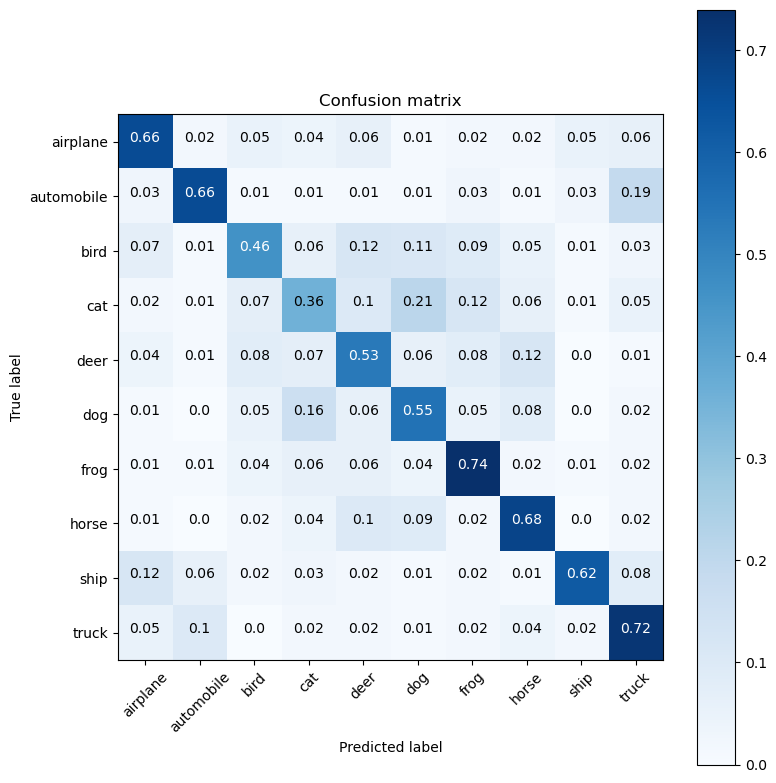

In [45]:
cnn_predictions, cnn_labels = validate(cnn_model, test_loader, cnn_loss_function,
                                     device, step=0, tb_logger=None)

import matplotlib.pyplot as plt
from utils import make_confusion_matrix
print("Test accuracy:")
accuracy = metrics.accuracy_score(cnn_labels, cnn_predictions)
print(accuracy)

fig, ax = plt.subplots(1, figsize=(8, 8))
make_confusion_matrix(cnn_labels, cnn_predictions, categories, ax)